# TAE-IA · Module 6 · L09 — OCR and Document Intelligence

| | |
|---|---|
| **Module** | 6 — Practical AI Applications: Images and Audio |
| **Lesson** | L09 |
| **Track** | A — Vision |
| **Estimated duration** | 2 hours |
| **GPU required** | T4 (Colab) — for TrOCR; Tesseract runs on CPU |
| **Prerequisites** | L08 cleanup cell run |

## Learning objectives
By the end of this notebook you will be able to:
- [ ] Run Tesseract on printed text with the correct PSM and language settings
- [ ] Build a preprocessing pipeline (binarization → denoise → deskew) and measure CER improvement
- [ ] Apply TrOCR to handwritten text lines and compare accuracy with Tesseract
- [ ] Diagnose OCR failure modes and propose appropriate fixes

## Before you start
- T4 GPU runtime selected
- L08 cleanup cell was run (~550 MB freed)

---

## Cell 0 — Setup (always run this first)

> Mounts Drive, checks GPU, fixes seed.

In [1]:
# ================================================================
# TAE-IA M6 · Standard Setup -- DO NOT MODIFY THIS CELL
# ================================================================
import os, sys, random, time, shutil
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

MODEL_CACHE = '/content/drive/MyDrive/TAE_IA_M6/models'   # persistent, survives sessions
LOCAL_CACHE = '/content/model_cache'                      # ephemeral, dies with the runtime
os.makedirs(MODEL_CACHE, exist_ok=True)
os.makedirs(LOCAL_CACHE, exist_ok=True)

# Clear any cache left by earlier course versions.
for _leftover in ('hub', 'xet'):
    _p = os.path.join(MODEL_CACHE, _leftover)
    if os.path.exists(_p):
        shutil.rmtree(_p)

# ----------------------------------------------------------------
# Model cache with automatic fallback
# ----------------------------------------------------------------
# Models are cached on Drive so they survive a session restart. A free
# Google account has only 15 GB, shared with Gmail and Photos, which is
# less than this course needs end to end. So when Drive has no room we
# cache on the runtime's own disk instead: the lab still runs, but that
# copy is deleted when the session ends.
#
# The choice is made per model, not once per notebook. A model already
# sitting on Drive keeps being read from Drive even when Drive is far
# too full to accept anything new.

DRIVE_HEADROOM_GB = 1.0    # never fill Drive to the last byte
SIZE_MARGIN       = 1.15   # temp files and metadata written during a download


def _free_gb(path):
    try:
        return shutil.disk_usage(path).free / 1e9
    except Exception:
        return 0.0


def _is_cached(path):
    """True if <path> holds anything but HuggingFace's incomplete-download folder."""
    return os.path.isdir(path) and any(e != '.cache' for e in os.listdir(path))


def _disk_full(exc):
    """ENOSPC, quota exceeded, or the I/O error drivefs raises when Drive is full."""
    return (getattr(exc, 'errno', None) in (28, 122, 5)
            or 'no space' in str(exc).lower()
            or 'quota' in str(exc).lower())


def cache_dir(name, needed_gb):
    """Return the directory model <name> should live in, preferring Drive."""
    drive_dir = os.path.join(MODEL_CACHE, name)
    local_dir = os.path.join(LOCAL_CACHE, name)

    if _is_cached(drive_dir):
        return drive_dir            # already on Drive: reading it costs no space
    if _is_cached(local_dir):
        return local_dir            # already fell back earlier this session

    required = needed_gb * SIZE_MARGIN + DRIVE_HEADROOM_GB
    free = _free_gb(MODEL_CACHE)
    if free >= required:
        os.makedirs(drive_dir, exist_ok=True)
        print(f'[cache] {name} -> Drive ({needed_gb:.2f} GB needed, {free:.1f} GB free).')
        return drive_dir

    local_free = _free_gb('/content')
    if local_free < required:
        raise RuntimeError(
            f'{name} needs ~{needed_gb:.1f} GB, but only {free:.1f} GB is free on '
            f'Drive and {local_free:.1f} GB on the runtime disk.\n'
            f'Free space in Google Drive (delete unused TAE_IA_M6/models subfolders) '
            f'and re-run this cell.')

    os.makedirs(local_dir, exist_ok=True)
    print(f'[cache] Not enough room on Drive for {name}: needs {needed_gb:.2f} GB\n'
          f'        plus margin, {free:.1f} GB free. Caching on the runtime instead.\n'
          f'        The lab runs normally, but this copy is deleted when the session\n'
          f'        ends and downloads again next time. Free space in Drive to avoid\n'
          f'        the repeat download.')
    return local_dir


def cached_fetch(name, needed_gb, download):
    """Run download(target_dir) in the best available cache and return its result.

    Retries on the runtime disk if Drive fills up mid-download: a pre-flight
    space check cannot catch a quota that runs out halfway through.
    """
    target = cache_dir(name, needed_gb)
    try:
        return download(target)
    except OSError as e:
        if not _disk_full(e) or target.startswith(LOCAL_CACHE):
            raise
        print(f'[cache] Drive ran out of room mid-download ({e}).\n'
              f'        Discarding the partial copy and retrying on the runtime disk.')
        shutil.rmtree(target, ignore_errors=True)
        fallback = os.path.join(LOCAL_CACHE, name)
        os.makedirs(fallback, exist_ok=True)
        return download(fallback)


def cached_snapshot(name, repo_id, needed_gb, **kwargs):
    """snapshot_download into the best available cache, returning its path."""
    from huggingface_hub import snapshot_download

    def _dl(target):
        snapshot_download(repo_id, local_dir=target, **kwargs)
        return target

    return cached_fetch(name, needed_gb, _dl)


_drive_free = _free_gb(MODEL_CACHE)
print(f'Model cache: {MODEL_CACHE}  ({_drive_free:.1f} GB free on Drive)')
if _drive_free < 1.0:
    print('WARNING: under 1 GB free on Drive. Models will cache on the runtime,\n'
          '         but saving your lab outputs may fail. Free space in Drive.')

import torch
if not torch.cuda.is_available():
    print('\nNo GPU detected. Go to: Runtime > Change runtime type > T4 GPU')
    raise SystemExit('GPU required.')

gpu_name = torch.cuda.get_device_name(0)
vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f'GPU: {gpu_name}  |  VRAM: {vram_gb:.1f} GB')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
print(f'Fixed seed: {SEED}')
print(f'Python {sys.version.split()[0]}  |  PyTorch {torch.__version__}')

Mounted at /content/drive
Model cache: /content/drive/MyDrive/TAE_IA_M6/models  (66.8 GB free on Drive)
GPU: Tesla T4  |  VRAM: 15.6 GB
Fixed seed: 42
Python 3.13.15  |  PyTorch 2.11.0+cu128


In [2]:
# ================================================================
# Install dependencies for L09
# ================================================================
!apt-get install -y tesseract-ocr tesseract-ocr-spa -q
!pip install pytesseract editdistance transformers accelerate Pillow -q

import pytesseract, editdistance, transformers
print(f'Tesseract: {pytesseract.get_tesseract_version()}')
print(f'transformers: {transformers.__version__}')
print(f'Available Tesseract languages: {pytesseract.get_languages()}')

Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
The following NEW packages will be installed:
  tesseract-ocr-spa
0 upgraded, 1 newly installed, 0 to remove and 57 not upgraded.
Need to get 951 kB of archives.
After this operation, 2,309 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-spa all 1:4.00~git30-7274cfa-1.1 [951 kB]
Fetched 951 kB in 2s (605 kB/s)
Selecting previously unselected package tesseract-ocr-spa.
(Reading database ... 122579 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-spa_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-spa (1:4.00~git30-7274cfa-1.1) ...
Setting up tesseract-ocr-spa (1:4.00~git30-7274cfa-1.1) ...
Tesseract: 4.1.1
transformers: 5.15.1
Available Tesseract languages: ['eng', 'osd', 'spa']


---
## Part 1 — Context and Key Concepts

> Read this before running any code.

### Tesseract vs. TrOCR: two fundamentally different approaches

**Tesseract** uses a classical pipeline: adaptive thresholding → line/word segmentation → per-character feature extraction → HMM + language model decoding. The core recognition step does not use a neural network. Its strength is speed (~0.1 s/page on CPU) and broad language support (100+ languages). Its weakness is sensitivity to image quality and font irregularity.

**TrOCR** uses a Vision Transformer encoder (BEiT) paired with a text decoder (RoBERTa-style). The model is trained end-to-end on (image, text) pairs, learning to recognize characters from raw pixels without any explicit segmentation step. It processes one line at a time and requires GPU for practical speed.

### Character Error Rate (CER)

CER = edit_distance(reference, prediction) / len(reference)

- CER = 0.00 → perfect
- CER = 0.05 → 5 errors per 100 characters (good for printed OCR)
- CER = 0.20 → 20 errors per 100 characters (borderline usable)
- CER > 0.30 → not usable without significant post-processing

### PSM (Page Segmentation Mode)

Tesseract's `--psm` flag tells it how to segment the image before recognition. Using the wrong PSM on a single-line image causes Tesseract to try splitting lines that don't exist, degrading accuracy significantly. Always match PSM to your document layout.

---

## Part 2 — Lab

### Section 2.1 — Generate test images

We create controlled test images programmatically so all students work with the same ground truth, regardless of download availability.

Printed-text font: /usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf


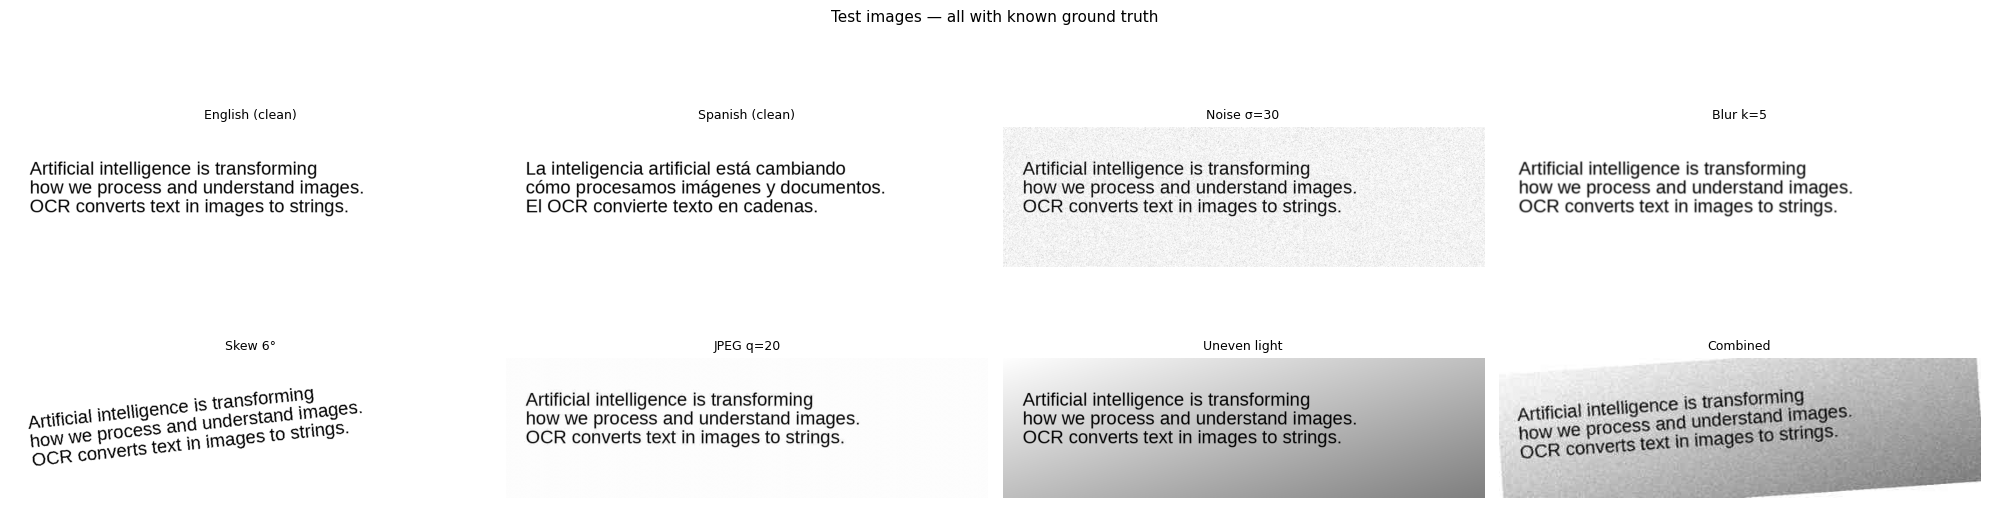

Test images saved to /content/drive/MyDrive/TAE_IA_M6/L09_output


In [3]:
# Section 2.1 — Generate test images with known ground truth
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import os

OUTPUT_DIR = '/content/drive/MyDrive/TAE_IA_M6/L09_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---- English printed text ----
ENGLISH_TEXT = (
    "Artificial intelligence is transforming\n"
    "how we process and understand images.\n"
    "OCR converts text in images to strings."
)

# ---- Spanish printed text ----
SPANISH_TEXT = (
    "La inteligencia artificial está cambiando\n"
    "cómo procesamos imágenes y documentos.\n"
    "El OCR convierte texto en cadenas."
)

# Font resolution, not a hardcoded path. The previous version pointed at the
# Debian dejavu path and, when that file was absent, render_text_image silently
# fell back to ImageFont.load_default() -- an ~11 px BITMAP font that ignores
# font_size completely. Every printed-text CER in Sections 2.2/2.3/2.5 was then
# measured on ~11 px glyphs no matter what font_size said, which is why raising
# font_size from 28 to 42 changed nothing. matplotlib always ships DejaVuSans,
# so the third candidate is a reliable backstop.
import glob
import matplotlib

FONT_CANDIDATES = [
    '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf',
    '/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf',
    os.path.join(os.path.dirname(matplotlib.__file__),
                 'mpl-data', 'fonts', 'ttf', 'DejaVuSans.ttf'),
]


def _resolve_font():
    for path in FONT_CANDIDATES:
        if os.path.exists(path):
            return path
    hits = sorted(glob.glob('/usr/share/fonts/**/*.ttf', recursive=True))
    if hits:
        return hits[0]
    raise RuntimeError(
        'No TrueType font found. This lab measures OCR accuracy against rendered '
        'text, so it cannot run on a bitmap fallback font.'
    )


DEJAVU = _resolve_font()
print('Printed-text font: {}'.format(DEJAVU))

# Canvas and font size matter more than they look. Tesseract is tuned for
# roughly 300 DPI scans; at the old 28 px / 800x200 the glyphs sat near its
# lower limit and it silently merged words ("processand"), so even the CLEAN
# baseline measured CER ~0.10 and every later number was taken against an
# already-broken reference. 42 px on a 1200x400 canvas puts clean text back
# near CER 0. The taller canvas also stops the 6-degree skew variant from
# rotating its own top line off the edge of the image.
def render_text_image(text, size=(1100, 320), font_size=42, bg=255, fg=0,
                      noise_sigma=0, blur_k=0, skew_deg=0, jpeg_q=100,
                      font_path=None, origin=(45, 70), illum=0.0,
                      downscale=1.0):
    """Render text to a PIL image with optional degradation."""
    img = Image.new('L', size, color=bg)
    draw = ImageDraw.Draw(img)
    chosen = font_path or DEJAVU
    try:
        font = ImageFont.truetype(chosen, font_size)
    except Exception as exc:
        # Deliberately fatal. ImageFont.load_default() would keep the notebook
        # running while ignoring font_size and rendering ~11 px text, which
        # silently invalidates every CER number downstream. A hard failure here
        # is far cheaper than plausible-looking wrong measurements.
        raise RuntimeError(
            'Could not load {!r} at {} px: {}'.format(chosen, font_size, exc)
        )
    draw.multiline_text(origin, text, font=font, fill=fg)

    arr = np.array(img, dtype=np.float32)

    # Uneven illumination: one corner lit, the opposite in shadow. This is what
    # a phone photo of a document actually looks like, and it is the ONLY
    # degradation adaptive thresholding exists to correct -- a global threshold
    # (which is what Tesseract applies internally) has to pick one cut point for
    # the whole page and necessarily gets it wrong at one end. Without this,
    # Section 2.3's threshold step has no job to do and measurably hurts.
    if illum > 0:
        h_i, w_i = arr.shape
        gy, gx = np.mgrid[0:h_i, 0:w_i]
        ramp = (gx / max(w_i - 1, 1) + gy / max(h_i - 1, 1)) / 2.0   # 0..1
        arr = arr * (1.0 - illum * ramp)

    if noise_sigma > 0:
        arr = np.clip(arr + np.random.normal(0, noise_sigma, arr.shape), 0, 255)

    if blur_k > 0:
        arr = cv2.GaussianBlur(arr.astype(np.uint8), (blur_k, blur_k), 0).astype(np.float32)

    img_out = Image.fromarray(arr.astype(np.uint8))

    if skew_deg != 0:
        img_out = img_out.rotate(skew_deg, fillcolor=bg, expand=False)

    # Low-resolution capture. This is the degradation that actually hurts a
    # printed-text OCR engine: Tesseract wants roughly 30 px of cap height
    # (~300 DPI), and below about 20 px its accuracy falls off a cliff. Noise
    # and blur barely dent 42 px glyphs -- shrinking them does. It is also what
    # gives the pipeline's upscale step a real job rather than a decorative one.
    if downscale < 1.0:
        new_w = max(1, int(img_out.width * downscale))
        new_h = max(1, int(img_out.height * downscale))
        img_out = img_out.resize((new_w, new_h), Image.BICUBIC)

    if jpeg_q < 100:
        from io import BytesIO
        buf = BytesIO()
        img_out.save(buf, format='JPEG', quality=jpeg_q)
        img_out = Image.open(BytesIO(buf.getvalue()))

    return img_out

# Clean printed images
doc_en_clean = render_text_image(ENGLISH_TEXT)
doc_es_clean = render_text_image(SPANISH_TEXT)

# Degraded variants for preprocessing experiment
doc_noisy    = render_text_image(ENGLISH_TEXT, noise_sigma=30)
doc_blurry   = render_text_image(ENGLISH_TEXT, blur_k=5)
doc_skewed   = render_text_image(ENGLISH_TEXT, skew_deg=6)
doc_jpeg     = render_text_image(ENGLISH_TEXT, jpeg_q=20)
# illum was 0.6/0.55 on the first attempt, which drove the shadowed end of the
# page down to ~115 grey. That is past the point where a global threshold
# merely struggles - it classifies the whole dark half as ink, and the raw
# baseline collapsed to CER 4.4 (unreadable garbage rather than a hard case).
# 0.5/0.4 is still plainly visible in the figure and still defeats a global
# cut point, while leaving the page recoverable.
doc_shadow   = render_text_image(ENGLISH_TEXT, illum=0.5)
# Calibrated against REAL 42 px glyphs. The earlier settings were tuned while
# the font was silently falling back to an ~11 px bitmap; against properly
# rendered text they left the raw document at CER 0.017, so no preprocessing
# step could demonstrate anything. downscale is the dominant knob here -- see
# the calibration note printed by Section 2.3.
doc_combined = render_text_image(ENGLISH_TEXT, noise_sigma=20, blur_k=3,
                                 skew_deg=4, jpeg_q=30, illum=0.5,
                                 downscale=0.5)

for name, img in [
    ('doc_en_clean', doc_en_clean), ('doc_es_clean', doc_es_clean),
    ('doc_noisy', doc_noisy), ('doc_blurry', doc_blurry),
    ('doc_skewed', doc_skewed), ('doc_jpeg', doc_jpeg),
    ('doc_shadow', doc_shadow),
    ('doc_combined', doc_combined),
]:
    img.save(os.path.join(OUTPUT_DIR, f'{name}.png'))

panels = [
    ('English (clean)', doc_en_clean), ('Spanish (clean)', doc_es_clean),
    ('Noise σ=30',      doc_noisy),    ('Blur k=5',        doc_blurry),
    ('Skew 6°',         doc_skewed),   ('JPEG q=20',       doc_jpeg),
    ('Uneven light',    doc_shadow),  ('Combined',        doc_combined),
]

# vmin/vmax are pinned to the full 8-bit range on purpose. Without them imshow
# auto-scales every panel to its own min/max, which exaggerates the contrast of
# the degraded panels and makes them look cleaner than they are.
fig, axes = plt.subplots(2, 4, figsize=(20, 6))
flat = axes.flatten()
for ax, (title, img) in zip(flat, panels):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=9); ax.axis('off')
for ax in flat[len(panels):]:          # 7 images in an 8-slot grid
    ax.axis('off')
plt.suptitle('Test images — all with known ground truth', fontsize=11)
plt.tight_layout(); plt.show()
print('Test images saved to', OUTPUT_DIR)

### Section 2.2 — Tesseract: language, PSM, and recognition engine


In [4]:
# Section 2.2 — Tesseract configuration experiment
import pytesseract, editdistance

def cer(reference, prediction):
    ref = reference.strip()
    pred = prediction.strip()
    return editdistance.eval(ref, pred) / max(len(ref), 1)

def ocr(img, lang='eng', psm=6):
    return pytesseract.image_to_string(
        img, lang=lang, config=f'--psm {psm} --oem 3'
    ).strip()

EN_REF = ENGLISH_TEXT.replace('\n', ' ').strip()
ES_REF = SPANISH_TEXT.replace('\n', ' ').strip()

print(f"{'Configuration':<35} | {'CER':>6} | Sample output")
print('-' * 90)

configs = [
    ('English, PSM 3 (auto)',    doc_en_clean, 'eng', 3,  EN_REF),
    ('English, PSM 6 (block)',   doc_en_clean, 'eng', 6,  EN_REF),
    ('Spanish, lang=eng',        doc_es_clean, 'eng', 6,  ES_REF),
    ('Spanish, lang=spa',        doc_es_clean, 'spa', 6,  ES_REF),
    ('Spanish, lang=eng+spa',    doc_es_clean, 'eng+spa', 6, ES_REF),
]

config_results = {}
for label, img, lang, psm, ref in configs:
    text      = ocr(img, lang=lang, psm=psm)
    c         = cer(ref, text)
    sample    = text.replace('\n', ' ')[:60]
    print(f"{label:<35} | {c:>5.3f} | {sample}")
    config_results[label] = (c, text)

Configuration                       |    CER | Sample output
------------------------------------------------------------------------------------------
English, PSM 3 (auto)               | 0.017 | Artificial intelligence is transforming how we process and u
English, PSM 6 (block)              | 0.017 | Artificial intelligence is transforming how we process and u
Spanish, lang=eng                   | 0.043 | La inteligencia artificial esta cambiando como procesamos im
Spanish, lang=spa                   | 0.017 | La inteligencia artificial está cambiando cómo procesamos im
Spanish, lang=eng+spa               | 0.026 | La inteligencia artificial esta cambiando cómo procesamos im


In [5]:
# Section 2.2 (cont.) - Legacy pattern classifier vs. LSTM engine
#
# Tesseract 4+ ships TWO recognisers inside the same binary: --oem 0 is the
# pre-2018 pattern classifier, --oem 1 is the LSTM line recogniser that has been
# the DEFAULT ever since. Most material describing "classical, non-neural OCR"
# is describing an engine you now have to ask for explicitly.
#
# Legacy needs legacy-trained data, which not every tessdata build ships. If it
# is missing here, that absence is itself the result - report it, do not hide it.

def ocr_oem(img, oem, lang='eng', psm=6):
    return pytesseract.image_to_string(
        img, lang=lang, config='--psm {} --oem {}'.format(psm, oem)).strip()


OEM_NAMES = {0: 'Legacy (pattern classifier)', 1: 'LSTM (default since 4.0)'}

print("{:<12} | {:<28} | {:>6} | Sample output".format('Image', 'Engine', 'CER'))
print('-' * 82)
for img_label, img_obj in [('Clean', doc_en_clean), ('Combined', doc_combined)]:
    for oem in (0, 1):
        try:
            out = ocr_oem(img_obj, oem)
            print("{:<12} | {:<28} | {:>6.3f} | {}".format(
                img_label, OEM_NAMES[oem], cer(EN_REF, out),
                out.replace(chr(10), ' ')[:30]))
        except Exception as exc:
            first = str(exc).split(chr(10))[0][:44]
            print("{:<12} | {:<28} |  n/a   | {}".format(
                img_label, OEM_NAMES[oem], first))

print('\nIf the legacy rows say n/a, this tessdata build ships LSTM data only.\n'
      'That is the practical answer to "is Tesseract still classical OCR?" -\n'
      'on a default install you often cannot even run the classical engine.')


Image        | Engine                       |    CER | Sample output
----------------------------------------------------------------------------------
Clean        | Legacy (pattern classifier)  |  n/a   | (1, "Error: Tesseract (legacy) engine reques
Clean        | LSTM (default since 4.0)     |  0.017 | Artificial intelligence is tra
Combined     | Legacy (pattern classifier)  |  n/a   | (1, "Error: Tesseract (legacy) engine reques
Combined     | LSTM (default since 4.0)     |  0.333 | OKApsi Artificial intelligence

If the legacy rows say n/a, this tessdata build ships LSTM data only.
That is the practical answer to "is Tesseract still classical OCR?" -
on a default install you often cannot even run the classical engine.


**What do you observe?**
- Which `lang` setting wins on the Spanish text, and are the errors on accented characters **systematic** or random? Systematic errors are evidence the end-of-pipeline language model is actively rewriting toward words that exist.
- Did PSM 3 or PSM 6 do better on a single block of text, and why would that flip on a multi-column page?
- **On `--oem`:** did the legacy engine run at all on this build? If it did, how far behind the LSTM engine is it — and on which image is the gap widest, the clean one or the degraded one? If it did not run, what does that tell you about calling Tesseract "classical, non-neural OCR" in 2026?


*Write your observation here (include specific character substitution examples):*

(double-click to edit)

### Section 2.3 — Preprocessing pipeline: step-by-step CER measurement

doc_combined was rendered with skew_deg=4; deskew estimated -4.0 deg

Stage                  |    CER | Sample output
--------------------------------------------------------------------------------------
Raw                    | 0.265 | Artificial intelligence is transforming. a how we process and understand images- Asean OCR converts text in images to strings. on hea sis aae Bee ¢
+ Flatten light        | 0.017 | Artificial intelligence is transforming how we process and understand images. OCR converts text in images to strings.
+ Denoise (grey)       | 0.017 | Artificial intelligence is transforming how we process and understand images. OCR converts text in images to strings.
+ Deskew (-4.0 deg)    | 0.017 | Artificial intelligence is transforming how we process and understand images. OCR converts text in images to strings.
+ Upscale x4.0         | 0.017 | Artificial intelligence is transforming how we process and understand images. OCR converts text in images to strings.
+ Threshol

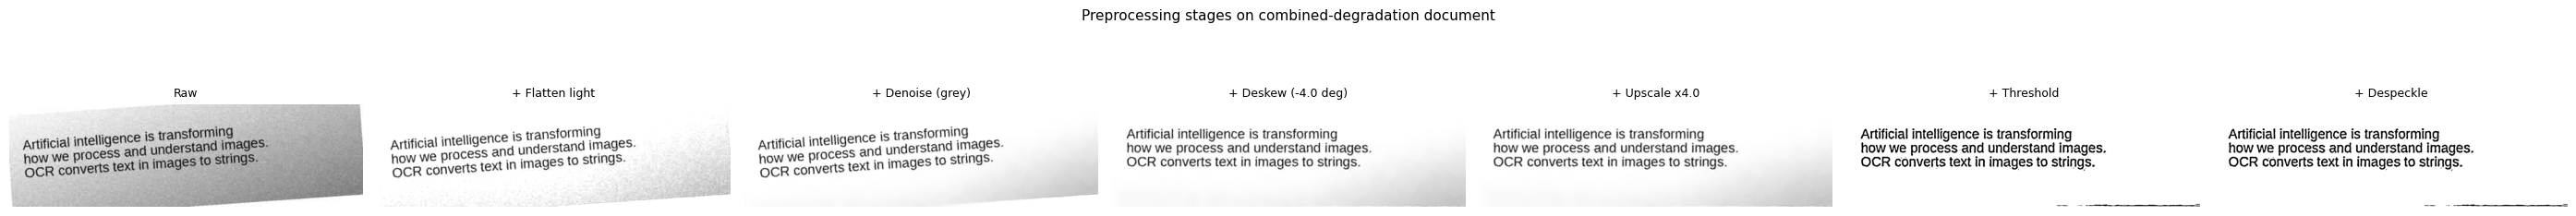

In [20]:
# Section 2.3 - Preprocessing pipeline with CER measurement at each step
#
# ORDER MATTERS, and it is the whole point of this section. The intuitive order
# ("binarise first, then clean up the binary image") is actively harmful:
# adaptive thresholding does not remove noise, it QUANTISES it to hard black,
# and nothing downstream can undo that. Denoise and deskew on the greyscale,
# while there is still intensity information to work with; binarise last.

def to_gray_np(pil_img):
    return np.array(pil_img.convert('L'))


def estimate_skew(mask, max_angle=15.0, step=0.5):
    """Find the rotation that best separates the rows of text.

    A page is straight when its rows of ink are maximally separated: dark rows
    very dark, gaps very light - i.e. the row-sum profile has maximum variance.
    Searching that score directly is robust on noisy pages. The previous
    Canny + HoughLines version fitted lines to whatever edges it found, which on
    a noisy page means fitting to noise, and returned an arbitrary angle.
    """
    h, w = mask.shape
    center = (w / 2, h / 2)
    best_angle, best_score = 0.0, -1.0
    for angle in np.arange(-max_angle, max_angle + step, step):
        M = cv2.getRotationMatrix2D(center, float(angle), 1.0)
        rot = cv2.warpAffine(mask, M, (w, h), flags=cv2.INTER_NEAREST,
                             borderValue=0)
        score = float(np.var(rot.sum(axis=1)))
        if score > best_score:
            best_score, best_angle = score, float(angle)
    if abs(best_angle) >= max_angle - 1e-9:
        # The optimum landing exactly on the search boundary means the score was
        # still climbing at the edge, i.e. we are not measuring text rows at all.
        # Refusing to rotate is far better than rotating by a made-up angle.
        print('  WARNING: skew search hit its {:+.0f} deg limit - ink mask looks '
              'wrong; leaving the page unrotated.'.format(max_angle))
        return 0.0
    return best_angle


def flatten_illumination(arr, sigma_frac=8.0):
    """Divide out the lighting field so the page has a uniform background.

    A heavy Gaussian blur of a page is a good estimate of its illumination:
    text is high-frequency and averages away, leaving only the lighting ramp.
    Dividing the page by that estimate flattens the gradient while leaving the
    strokes intact - classic flat-field correction.

    This has to come FIRST. Every later stage assumes an evenly-lit page, and so
    does Tesseract's own internal global threshold: on a shadowed page a single
    cut point is wrong at one end no matter where you put it.
    """
    a = arr.astype(np.float32)
    bg = cv2.GaussianBlur(a, (0, 0), sigmaX=max(arr.shape) / sigma_frac)
    return np.clip(a / np.maximum(bg, 1.0) * 255.0, 0, 255).astype(np.uint8)


def step_flatten(arr):
    return flatten_illumination(arr)


def _ink_mask(arr):
    """Illumination-invariant ink mask, used for geometry estimation only.

    Otsu on the raw greyscale is not safe here: on a strongly shadowed page it
    puts the cut inside the background ramp and labels the entire dark half as
    ink. The skew search then sees one huge blob instead of text rows and runs
    to its angle limit (this is exactly how deskew reported -15 deg for a
    +4 deg render). Flattening first makes the mask mean what it says.
    """
    _, mask = cv2.threshold(flatten_illumination(arr), 0, 255,
                            cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)
    return mask


def deskew(img_np, return_angle=False):
    """Estimate skew from the ink mask and rotate it out."""
    angle = estimate_skew(_ink_mask(img_np))
    h, w = img_np.shape
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    # BORDER_REPLICATE, not a constant fill: pasting pure white into the corners
    # of a grey page creates a hard diagonal edge, and the adaptive threshold
    # then renders it as a black line straight across the document.
    out = cv2.warpAffine(img_np, M, (w, h),
                         flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
    return (out, angle) if return_angle else out


def step_denoise(arr):
    """Non-local means on the GREYSCALE image, before any binarisation.

    This is the step that actually removes Gaussian sensor noise. Morphological
    opening on an already-binarised image (the previous approach) cannot: by
    then the noise is fused into multi-pixel blobs, and the kernel erodes the
    thin strokes as readily as the speckles.
    """
    return cv2.fastNlMeansDenoising(arr.astype(np.uint8), None,
                                    h=12, templateWindowSize=7,
                                    searchWindowSize=21)


def step_deskew(arr):
    return deskew(arr)


def step_upscale(arr, target_h=640):
    """Upscale to clear Tesseract's resolution floor.

    A fixed x2 is not enough when the capture was low-resolution to begin with,
    and pointless when it already has pixels to spare. Scale toward a target
    height instead, and do nothing if the page is already above it.
    """
    if arr.shape[0] >= target_h:
        return arr
    f = target_h / float(arr.shape[0])
    return cv2.resize(arr, None, fx=f, fy=f, interpolation=cv2.INTER_CUBIC)


def step_threshold(arr, C=5):
    """Adaptive threshold with a window that scales with the image.

    Two fixes over the fixed (31, 10): the block size is tied to image height,
    because after a 2x upscale a 31 px window covers half the relative area it
    used to and starts thresholding *inside* a stroke rather than across it;
    and C drops from 10 to 5, because on blurred/JPEG-softened edges a large C
    shaves the stroke edges and thins glyphs until they break apart.
    """
    block = max(15, int(arr.shape[0] * 0.08) | 1)      # | 1 forces it odd
    return cv2.adaptiveThreshold(
        arr.astype(np.uint8), 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, block, C
    )


def step_despeckle(arr):
    """Drop connected components too small to be text.

    Morphological opening erodes EVERY component, so it thins the strokes it is
    meant to preserve - on this document it cost more accuracy than the specks
    did. An area filter is the right tool: it deletes only components below a
    plausible glyph size and leaves the survivors at full stroke width.
    """
    min_area = max(6, int((arr.shape[0] / 200.0) ** 2))
    ink = (arr == 0).astype(np.uint8)
    n, labels, stats, _ = cv2.connectedComponentsWithStats(ink, connectivity=8)
    out = np.full_like(arr, 255)
    for i in range(1, n):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            out[labels == i] = 0
    return out


# Apply the pipeline step-by-step on the combined degradation
arr = to_gray_np(doc_combined)
stages = [('Raw', Image.fromarray(arr))]

arr = step_flatten(arr)
stages.append(('+ Flatten light', Image.fromarray(arr)))

arr = step_denoise(arr)
stages.append(('+ Denoise (grey)', Image.fromarray(arr)))

arr, est_angle = deskew(arr, return_angle=True)
stages.append(('+ Deskew ({:+.1f} deg)'.format(est_angle), Image.fromarray(arr)))

_h_before = arr.shape[0]
arr = step_upscale(arr)
stages.append(('+ Upscale x{:.1f}'.format(arr.shape[0] / _h_before),
               Image.fromarray(arr)))

arr = step_threshold(arr)
stages.append(('+ Threshold', Image.fromarray(arr)))

arr = step_despeckle(arr)
stages.append(('+ Despeckle', Image.fromarray(arr)))

print('doc_combined was rendered with skew_deg=4; deskew estimated '
      '{:+.1f} deg\n'.format(est_angle))

print("{:<22} | {:>6} | Sample output".format('Stage', 'CER'))
print('-' * 86)
stage_cers = []
for name, img in stages:
    text = ocr(img, lang='eng', psm=6)
    c = cer(EN_REF, text)
    stage_cers.append((name, c))
    print("{:<22} | {:>5.3f} | {}".format(name, c, text.replace(chr(10), ' ')))

best_name, best_cer = min(stage_cers, key=lambda t: t[1])
final_name, final_cer = stage_cers[-1]
print('\nBest stage : {} (CER {:.3f})'.format(best_name, best_cer))
print('Final stage: {} (CER {:.3f})'.format(final_name, final_cer))
raw_stage_cer = stage_cers[0][1]
if raw_stage_cer < 0.10:
    print('\nCALIBRATION: the raw document scores CER {:.3f} - it is too easy for\n'
          'any preprocessing step to show a measurable gain. Lower `downscale` on\n'
          "doc_combined in Section 2.1 (0.5 -> 0.4) and re-run from there."
          .format(raw_stage_cer))
elif raw_stage_cer > 1.0:
    print('\nCALIBRATION: the raw document scores CER {:.3f} - that is garbage output\n'
          'rather than a hard case, and the stage-by-stage numbers will not be\n'
          'meaningful. Raise `downscale` on doc_combined in Section 2.1\n'
          "(0.5 -> 0.6) and re-run from there.".format(raw_stage_cer))

if best_cer < final_cer - 1e-9:
    print('\nNote: a later step UNDID some of the gain. That is a real result, not a\n'
          'bug - report it in 4.1. Every step in a preprocessing pipeline has to\n'
          'earn its place on measured CER, and steps that help one document can\n'
          'hurt another.')

# ---------------------------------------------------------------------------
# Ablation: each step applied ALONE to the raw document.
#
# The table above is cumulative, so as soon as one step reaches Tesseract's
# error floor every later step reads as zero improvement - which makes those
# steps look useless when they are only masked. Question 4.1 asks which SINGLE
# step helped most, and a cumulative table structurally cannot answer that.
#
# step_despeckle is excluded: it operates on a binarised image, so "applied
# alone to the greyscale" is not a meaningful thing to measure.
# ---------------------------------------------------------------------------
raw_arr = to_gray_np(doc_combined)
raw_only_cer = cer(EN_REF, ocr(Image.fromarray(raw_arr), lang='eng', psm=6))

print('\n{:<20} | {:>6} | {:>8}'.format('Step applied ALONE', 'CER', 'vs raw'))
print('-' * 40)
print('{:<20} | {:>6.3f} | {:>8}'.format('(none - raw)', raw_only_cer, '--'))
for _name, _fn in [('Flatten light', step_flatten),
                   ('Denoise',       step_denoise),
                   ('Deskew',        step_deskew),
                   ('Upscale',       step_upscale),
                   ('Threshold',     step_threshold)]:
    _c = cer(EN_REF, ocr(Image.fromarray(_fn(raw_arr.copy())), lang='eng', psm=6))
    print('{:<20} | {:>6.3f} | {:>+8.3f}'.format(_name, _c, _c - raw_only_cer))

# Visualise all stages
fig, axes = plt.subplots(1, len(stages), figsize=(4 * len(stages), 3))
for ax, (name, img) in zip(axes, stages):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(name, fontsize=9)
    ax.axis('off')
plt.suptitle('Preprocessing stages on combined-degradation document', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'preprocessing_stages.png'), dpi=100)
plt.show()


**What do you observe?**  
- Which single preprocessing step produced the largest CER drop?
- Did deskew help or hurt in your specific case? Why might it hurt when the skew estimate is wrong?
- What is the final CER of the full pipeline vs. the raw image?

*Write your observation here (include CER numbers for each stage):*

(double-click to edit)

### Section 2.4 — TrOCR on handwritten text

Handwriting font: Caveat.ttf


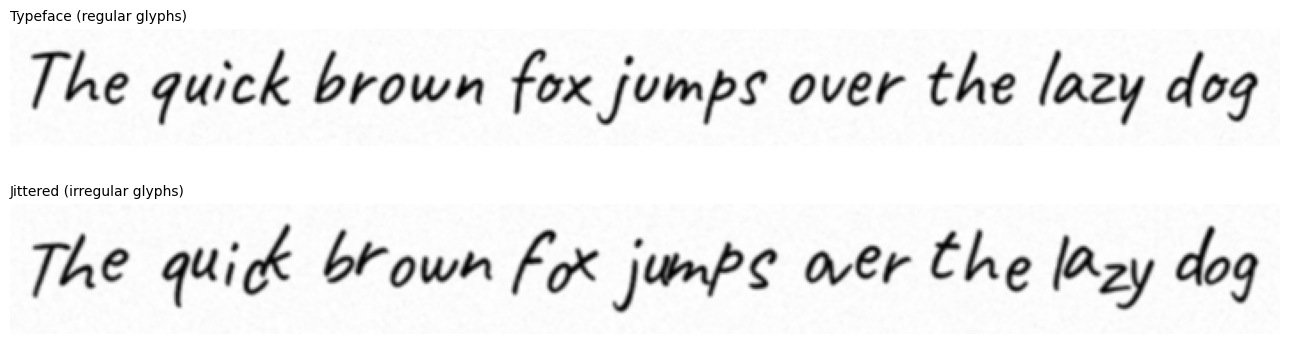

Ground truth (both samples): "The quick brown fox jumps over the lazy dog"


In [7]:
# Section 2.4 — Render a handwriting test line with EXACT ground truth
#
# The previous version of this cell downloaded a scanned handwriting photo from
# Wikimedia and paired it with a hardcoded ground-truth string that was never
# that image's actual text — so the CER below was meaningless even when the
# download worked. Rendering the line ourselves from a real handwriting
# typeface keeps the ground truth exact and reproducible.
import urllib.request

FONT_DIR = '/content/fonts'
os.makedirs(FONT_DIR, exist_ok=True)

# Google Fonts, OFL-licensed. Caveat is slanted and loosely joined, which is
# the property that makes it hard for a printed-text engine like Tesseract.
HANDWRITING_FONTS = [
    ('Caveat.ttf',
     'https://github.com/google/fonts/raw/main/ofl/caveat/Caveat%5Bwght%5D.ttf'),
    ('IndieFlower-Regular.ttf',
     'https://github.com/google/fonts/raw/main/ofl/indieflower/IndieFlower-Regular.ttf'),
]

HW_FONT_PATH = None
for fname, furl in HANDWRITING_FONTS:
    dest = os.path.join(FONT_DIR, fname)
    try:
        if not os.path.exists(dest):
            urllib.request.urlretrieve(furl, dest)
        ImageFont.truetype(dest, 40)          # prove PIL can actually open it
        HW_FONT_PATH = dest
        print(f'Handwriting font: {fname}')
        break
    except Exception as e:
        print(f'  {fname} unavailable ({e}) — trying next')

if HW_FONT_PATH is None:
    raise RuntimeError(
        'No handwriting font could be downloaded. Section 2.4 compares TrOCR '
        'against Tesseract on handwriting; running it with the printed DejaVu '
        'font would compare them on printed text instead and prove nothing. '
        'Check the runtime network connection and re-run this cell.'
    )

HANDWRITING_GT = 'The quick brown fox jumps over the lazy dog'

# ---------------------------------------------------------------------------
# Two samples, not one. This is the point of the section.
#
# A handwriting TYPEFACE draws every 'e' identically, so to an OCR engine it is
# just an unusual printed font - Tesseract handles it easily, and comparing the
# two engines on it tells you nothing about handwriting. Real handwriting varies
# from glyph to glyph, and that variation is precisely what TrOCR was trained on
# (IAM: photographed human writing) and what Tesseract's character segmentation
# assumes away.
#
# So we render both: the regular typeface line, and the same text with per-glyph
# rotation, size, baseline and spacing jitter. Rendering rather than downloading
# keeps the ground truth exact and needs no network; the fixed seed keeps it
# reproducible across the class.
# ---------------------------------------------------------------------------

def render_handwriting(text, font_path, font_size=48, size=(1400, 170),
                       jitter=True, seed=0, noise_sigma=6, blur_k=3):
    """Render a line glyph-by-glyph, optionally jittering each character."""
    rng = np.random.default_rng(seed)
    img = Image.new('L', size, color=255)
    pad = font_size
    x = 30.0
    base = size[1] // 2

    for ch in text:
        fsize = font_size + (int(rng.integers(-3, 4)) if jitter else 0)
        font = ImageFont.truetype(font_path, fsize)

        if ch == ' ':
            x += font.getlength(' ') * (rng.uniform(0.9, 1.4) if jitter else 1.0)
            continue

        # Each glyph is drawn on its own tile so it can be rotated in isolation.
        tile = Image.new('L', (fsize + 2 * pad, fsize + 2 * pad), color=0)
        ImageDraw.Draw(tile).text((pad, pad), ch, font=font, fill=255)

        if jitter:
            tile = tile.rotate(rng.uniform(-8, 8), resample=Image.BICUBIC)
            dy = rng.uniform(-0.10, 0.10) * font_size
        else:
            dy = 0.0

        # paste(colour, box, mask): stamps black ink wherever the tile has ink.
        img.paste(0, (int(x - pad), int(base - fsize - pad + dy)), tile)
        x += font.getlength(ch) * (rng.uniform(0.86, 1.04) if jitter else 1.0)

    arr = np.array(img, dtype=np.float32)
    if noise_sigma > 0:
        arr = np.clip(arr + rng.normal(0, noise_sigma, arr.shape), 0, 255)
    out = arr.astype(np.uint8)
    if blur_k > 0:
        out = cv2.GaussianBlur(out, (blur_k, blur_k), 0)
    return Image.fromarray(out).convert('RGB')


def crop_to_ink(pil_img, pad=12, bg_thresh=200):
    """Crop to the ink bounding box.

    TrOCR was trained on IAM line images, which are cropped tight to the text.
    A wide blank margin is out of domain and reliably tips the decoder into
    degeneration: it reads the sentence correctly and then keeps emitting
    ("... lazy dog 3 .000500050000"), which wrecks CER even though the reading
    was right. Tesseract does not care either way, so cropping costs it nothing
    and keeps both engines on the same image.
    """
    arr = np.array(pil_img.convert('L'))
    ys, xs = np.where(arr < bg_thresh)
    if len(xs) == 0:
        return pil_img
    x0 = max(int(xs.min()) - pad, 0)
    x1 = min(int(xs.max()) + pad + 1, arr.shape[1])
    y0 = max(int(ys.min()) - pad, 0)
    y1 = min(int(ys.max()) + pad + 1, arr.shape[0])
    return pil_img.crop((x0, y0, x1, y1))


# Sample A - the handwriting typeface, perfectly regular
hw_typeface = render_text_image(
    HANDWRITING_GT,
    size=(1400, 160), font_size=48, origin=(30, 45),
    noise_sigma=6, blur_k=3,
    font_path=HW_FONT_PATH,
).convert('RGB')

# Sample B - the same text with per-glyph variation
hw_jittered = render_handwriting(HANDWRITING_GT, HW_FONT_PATH, seed=SEED)

hw_typeface = crop_to_ink(hw_typeface)
hw_jittered = crop_to_ink(hw_jittered)

HW_SAMPLES = [
    ('Typeface (regular glyphs)', hw_typeface),
    ('Jittered (irregular glyphs)', hw_jittered),
]

hw_typeface.save(os.path.join(OUTPUT_DIR, 'handwriting_typeface.png'))
hw_jittered.save(os.path.join(OUTPUT_DIR, 'handwriting_jittered.png'))

fig, axes = plt.subplots(len(HW_SAMPLES), 1, figsize=(13, 4))
for ax, (name, img) in zip(axes, HW_SAMPLES):
    ax.imshow(img)
    ax.set_title(name, fontsize=10, loc='left')
    ax.axis('off')
plt.tight_layout()
plt.show()
print('Ground truth (both samples): "{}"'.format(HANDWRITING_GT))


In [8]:
# Section 2.4 (cont.) — Load TrOCR handwritten model
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
import torch

TROCR_MODEL = 'microsoft/trocr-base-handwritten'

# Not gated, no fp16-suffixed variant (single precision only) -- configs + one weight
# format, skip the .bin duplicate.
TROCR_DIR = cached_snapshot(
    'trocr-base-handwritten-local',
    TROCR_MODEL,
    needed_gb=1.33,
    allow_patterns=["*.json", "*.txt", "*.safetensors"],
)

def ensure_fast_tokenizer(model_dir):
    """Build tokenizer.json for a TrOCR snapshot that ships only slow-tokenizer files.

    Both microsoft/trocr-base-handwritten and microsoft/trocr-base-printed ship a
    *slow* RobertaTokenizer - vocab.json + merges.txt - and no tokenizer.json;
    check either repo's file list, it really is not there. transformers v5, which
    Colab now installs, dropped the slow->fast conversion path, so
    TrOCRProcessor.from_pretrained raises "Couldn't instantiate the backend
    tokenizer". Building tokenizer.json once from the byte-level BPE files the
    repos DO ship fixes it without pinning transformers back to v4.

    (That error names sentencepiece. Red herring: this is byte-level BPE, and
    installing sentencepiece does not help.)
    """
    from tokenizers import Tokenizer, models, pre_tokenizers, decoders, processors

    tok_json = os.path.join(model_dir, 'tokenizer.json')
    if os.path.exists(tok_json):
        return tok_json

    tk = Tokenizer(models.BPE.from_file(
        os.path.join(model_dir, 'vocab.json'),
        os.path.join(model_dir, 'merges.txt'),
        unk_token='<unk>',
    ))
    tk.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
    tk.decoder = decoders.ByteLevel()
    tk.post_processor = processors.RobertaProcessing(
        sep=('</s>', tk.token_to_id('</s>')),
        cls=('<s>', tk.token_to_id('<s>')),
        add_prefix_space=False,
    )
    # Mark them special so batch_decode(skip_special_tokens=True) strips them.
    tk.add_special_tokens(['<s>', '<pad>', '</s>', '<unk>', '<mask>'])
    tk.save(tok_json)
    print('  built tokenizer.json in {}'.format(os.path.basename(model_dir)))
    return tok_json


ensure_fast_tokenizer(TROCR_DIR)
processor   = TrOCRProcessor.from_pretrained(TROCR_DIR)
trocr_model = VisionEncoderDecoderModel.from_pretrained(
    TROCR_DIR, torch_dtype=torch.float16
).to('cuda')
trocr_model.eval()
print(f'TrOCR loaded: {TROCR_MODEL}')

def trocr_predict(pil_image):
    pv  = processor(images=pil_image.convert('RGB'),
                    return_tensors='pt').pixel_values
    pv  = pv.to('cuda', dtype=torch.float16)
    with torch.no_grad():
        ids = trocr_model.generate(pv, max_new_tokens=128)
    return processor.batch_decode(ids, skip_special_tokens=True)[0]

[cache] trocr-base-handwritten-local -> Drive (1.33 GB needed, 66.7 GB free).


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

  built tokenizer.json in trocr-base-handwritten-local


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: /content/drive/MyDrive/TAE_IA_M6/models/trocr-base-handwritten-local
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


TrOCR loaded: microsoft/trocr-base-handwritten


Ground truth: The quick brown fox jumps over the lazy dog

Sample                       |  TrOCR CER |   Tess CER
------------------------------------------------------
Typeface (regular glyphs)    |      0.000 |      0.000
Jittered (irregular glyphs)  |      0.000 |      0.140

Degradation from regular to irregular glyphs:
  TrOCR     : +0.000
  Tesseract : +0.140

Full outputs
------------------------------------------------------

Typeface (regular glyphs)
  TrOCR     (2.93s) CER=0.000: The quick brown fox jumps over the lazy dog
  Tesseract (0.795s) CER=0.000: The quick brown fox jumps over the lazy dog

Jittered (irregular glyphs)
  TrOCR     (0.45s) CER=0.000: The quick brown fox jumps over the lazy dog
  Tesseract (0.854s) CER=0.140: The quick brown Fox jars aer the lazy dog


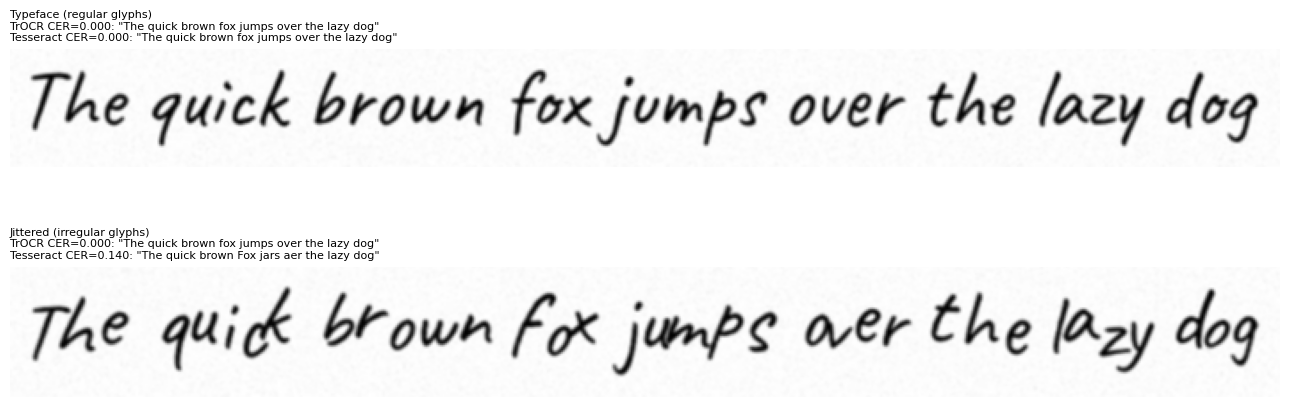

In [9]:
# Section 2.4 (cont.) - Compare TrOCR vs. Tesseract on handwriting
#
# Both engines, both samples. Read the table by COLUMN, not by row: the
# interesting quantity is how much each engine degrades when the glyphs stop
# being identical, not which engine wins on any single line.

hw_results = []
for sample_name, img in HW_SAMPLES:
    t0 = time.time()
    trocr_text = trocr_predict(img)
    t_trocr = time.time() - t0

    t0 = time.time()
    tess_text = ocr(img, lang='eng', psm=7)      # PSM 7 = single line
    t_tess = time.time() - t0

    hw_results.append({
        'sample': sample_name,
        'trocr_text': trocr_text, 'trocr_cer': cer(HANDWRITING_GT, trocr_text),
        'trocr_time': t_trocr,
        'tess_text': tess_text.replace(chr(10), ' '),
        'tess_cer': cer(HANDWRITING_GT, tess_text),
        'tess_time': t_tess,
    })

print('Ground truth: {}\n'.format(HANDWRITING_GT))
print("{:<28} | {:>10} | {:>10}".format('Sample', 'TrOCR CER', 'Tess CER'))
print('-' * 54)
for r in hw_results:
    print("{:<28} | {:>10.3f} | {:>10.3f}".format(
        r['sample'], r['trocr_cer'], r['tess_cer']))

print('\nDegradation from regular to irregular glyphs:')
print('  TrOCR     : {:+.3f}'.format(
    hw_results[1]['trocr_cer'] - hw_results[0]['trocr_cer']))
print('  Tesseract : {:+.3f}'.format(
    hw_results[1]['tess_cer'] - hw_results[0]['tess_cer']))

print('\nFull outputs')
print('-' * 54)
for r in hw_results:
    print('\n{}'.format(r['sample']))
    print('  TrOCR     ({:.2f}s) CER={:.3f}: {}'.format(
        r['trocr_time'], r['trocr_cer'], r['trocr_text']))
    print('  Tesseract ({:.3f}s) CER={:.3f}: {}'.format(
        r['tess_time'], r['tess_cer'], r['tess_text']))

fig, axes = plt.subplots(len(HW_SAMPLES), 1, figsize=(13, 5))
for ax, (name, img), r in zip(axes, HW_SAMPLES, hw_results):
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(
        '{}\nTrOCR CER={:.3f}: "{}"\nTesseract CER={:.3f}: "{}"'.format(
            name, r['trocr_cer'], r['trocr_text'][:60],
            r['tess_cer'], r['tess_text'][:60]),
        fontsize=8, loc='left')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'handwriting_comparison.png'), dpi=100)
plt.show()


**What do you observe?**
- On the **regular typeface** line, which engine won? Is that result about handwriting, or about the glyphs being identical every time?
- On the **jittered** line, how much did each engine's CER move? Compare the two deltas printed by the cell.
- TrOCR is an end-to-end transformer with a language-model decoder; Tesseract segments characters and classifies them. Which of those two designs should care more about glyph-to-glyph consistency, and does your result match?
- Was TrOCR's inference time acceptable for a real application?


*Write your observation here (include CER values and specific error examples):*

(double-click to edit)

### Section 2.5 — Full document pipeline: photo → preprocessing → OCR → clean text

Ground truth:
Artificial intelligence is transforming
how we process and understand images.
OCR converts text in images to strings.

No preprocessing  : CER=0.265
Full pipeline     : CER=0.026

Pipeline output:
Artificial intelligence is transforming
how we process.and understand images.
OCR converts text in images to strings.


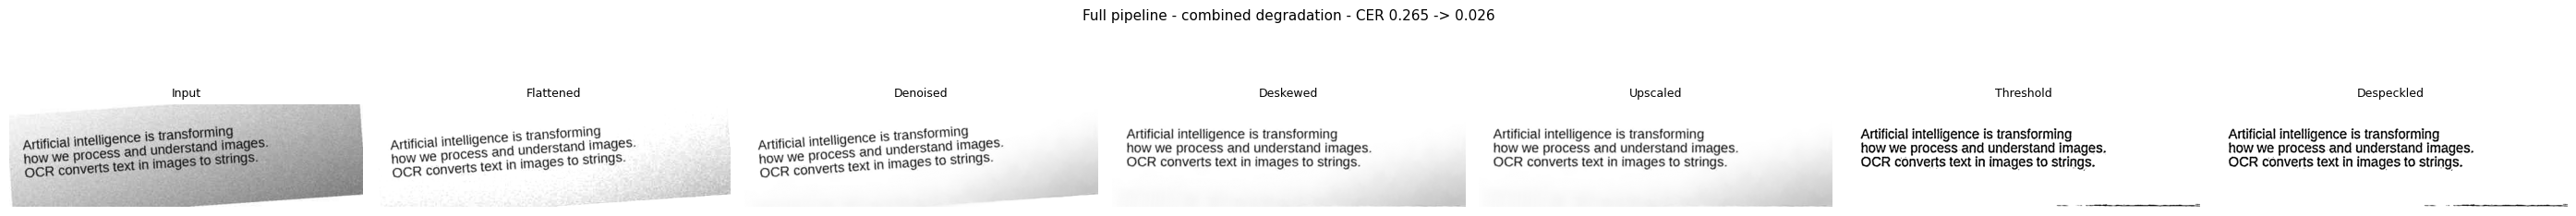

In [10]:
# Section 2.5 - End-to-end pipeline on a realistic noisy document

def full_ocr_pipeline(pil_img, lang='eng'):
    """Preprocessing + Tesseract. Returns (clean_text, intermediate_images).

    Same ordering rule as Section 2.3: clean and straighten on the greyscale,
    binarise last.
    """
    stages = [('Input', pil_img.convert('L'))]
    arr = np.array(stages[-1][1])

    arr = step_flatten(arr)
    stages.append(('Flattened', Image.fromarray(arr)))

    arr = step_denoise(arr)
    stages.append(('Denoised', Image.fromarray(arr)))

    arr = step_deskew(arr)
    stages.append(('Deskewed', Image.fromarray(arr)))

    # step_upscale is self-guarding: it scales toward a target height and is a
    # no-op on a page that already has the resolution.
    _h = arr.shape[0]
    arr = step_upscale(arr)
    if arr.shape[0] != _h:
        stages.append(('Upscaled', Image.fromarray(arr)))

    arr = step_threshold(arr)
    stages.append(('Threshold', Image.fromarray(arr)))

    arr = step_despeckle(arr)
    stages.append(('Despeckled', Image.fromarray(arr)))

    text = ocr(Image.fromarray(arr), lang=lang, psm=6)
    return text, stages


result_text, pipeline_stages = full_ocr_pipeline(doc_combined, lang='eng')
pipeline_cer = cer(EN_REF, result_text)

# Baseline: the same document with no preprocessing at all. If the pipeline is
# not beating this, the pipeline is not earning its place.
raw_cer = cer(EN_REF, ocr(doc_combined.convert('L'), lang='eng', psm=6))

print('Ground truth:\n{}'.format(ENGLISH_TEXT))
print('\nNo preprocessing  : CER={:.3f}'.format(raw_cer))
print('Full pipeline     : CER={:.3f}'.format(pipeline_cer))
print('\nPipeline output:\n{}'.format(result_text))

fig, axes = plt.subplots(1, len(pipeline_stages),
                         figsize=(4 * len(pipeline_stages), 3))
for ax, (name, img) in zip(axes, pipeline_stages):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(name, fontsize=9)
    ax.axis('off')
plt.suptitle('Full pipeline - combined degradation - CER {:.3f} -> {:.3f}'.format(
    raw_cer, pipeline_cer), fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'full_pipeline.png'), dpi=100)
plt.show()


### Section 2.6 — Per-word confidence and a routing threshold

`image_to_string` returns a string and discards everything else Tesseract computed. `image_to_data` returns the full table: one row per word, with its bounding box and a confidence from 0 to 100.

This is the difference between using OCR once and building an OCR *system*. A production document pipeline is not one whose OCR never fails — that does not exist — it is one that knows when it probably failed and routes those cases to a person.


Image                      | words | mean conf |     < 60
--------------------------------------------------------------
Clean                      |    17 |      95.9 |        0
Combined (raw)             |    25 |      57.3 |       12
    flagged: OKApsi(0), Artificial(53), ag(42), 7(43), how(16), images:(59)
Combined (preprocessed)    |    16 |      95.4 |        0


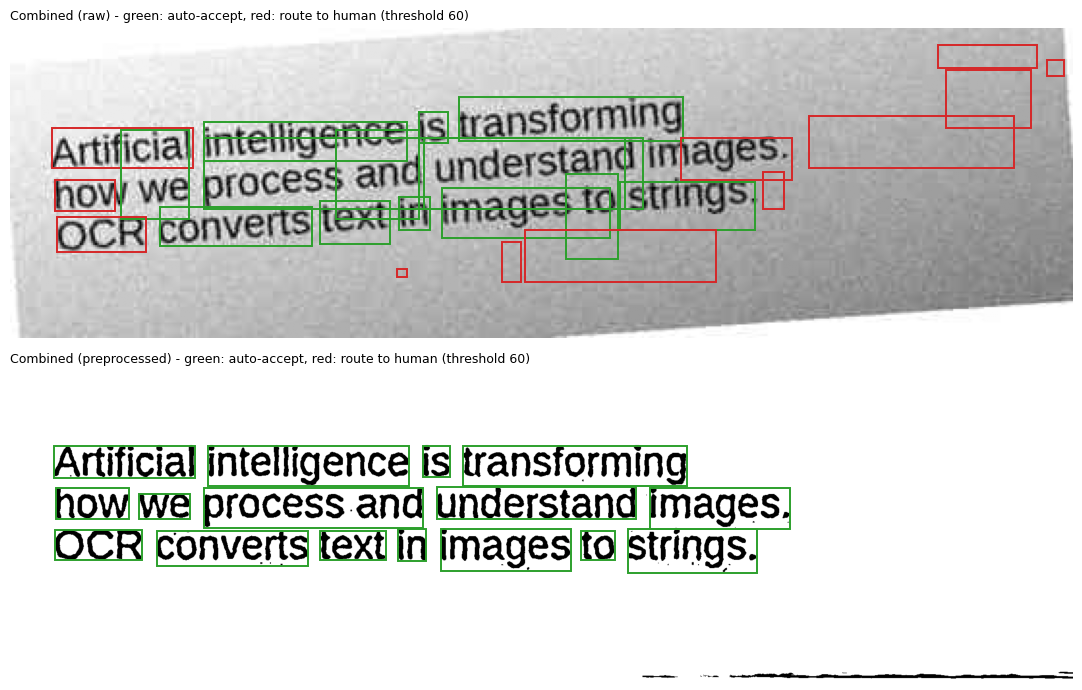


Routing at confidence >= 60: 16/16 words auto-accepted (100%), 0 sent for human review.

Caveat: confidence is a triage signal, NOT a calibrated probability.
A word misread from clean, sharp print can still score above 90 - the
classic case is "rn" read as "m". Use it to prioritise review, never as
proof that a field is correct.


In [11]:
# Section 2.6 - Per-word confidence and a routing threshold
#
# image_to_string throws away the most useful thing Tesseract computes.
# image_to_data keeps it: one row per detected word, with a bounding box and a
# confidence from 0 to 100.
#
# This matters because OCR output has NO notion of "I don't know". A misread
# word comes back looking exactly as ordinary as a correct one - CER tells you
# five characters in a hundred are wrong, but not WHICH five. Confidence is the
# only per-word signal you get.
from pytesseract import Output

CONF_THRESHOLD = 60


def word_confidences(img, lang='eng', psm=6):
    """Return [(text, conf, (x, y, w, h)), ...] for real words only."""
    d = pytesseract.image_to_data(
        img, lang=lang, config='--psm {} --oem 3'.format(psm),
        output_type=Output.DICT)
    rows = []
    for i, txt in enumerate(d['text']):
        conf = float(d['conf'][i])
        # conf == -1 marks layout blocks holding no text at all. Forgetting to
        # filter them is the classic bug: they flood any low-confidence list.
        if txt.strip() and conf >= 0:
            rows.append((txt, conf, (d['left'][i], d['top'][i],
                                     d['width'][i], d['height'][i])))
    return rows


# The degraded page put through the Section 2.3 pipeline, for a before/after
prep_combined = Image.fromarray(
    step_threshold(step_upscale(step_deskew(step_denoise(
        step_flatten(to_gray_np(doc_combined)))))))

PANELS = [('Clean', doc_en_clean),
          ('Combined (raw)', doc_combined),
          ('Combined (preprocessed)', prep_combined)]

print("{:<26} | {:>5} | {:>9} | {:>8}".format(
    'Image', 'words', 'mean conf', '< {}'.format(CONF_THRESHOLD)))
print('-' * 62)
for label, img_obj in PANELS:
    rows = word_confidences(img_obj)
    if not rows:
        print("{:<26} | {:>5} | {:>9} | {:>8}".format(label, 0, '--', '--'))
        continue
    confs = [c for _, c, _ in rows]
    low = [(t, c) for t, c, _ in rows if c < CONF_THRESHOLD]
    print("{:<26} | {:>5} | {:>9.1f} | {:>8}".format(
        label, len(rows), float(np.mean(confs)), len(low)))
    if low:
        print('    flagged: ' + ', '.join(
            '{}({:.0f})'.format(t, c) for t, c in low[:6]))

# Where does low confidence LIVE? Green = auto-accept, red = route to a human.
fig, axes = plt.subplots(2, 1, figsize=(13, 7))
for ax, (label, img_obj) in zip(axes, PANELS[1:]):
    ax.imshow(img_obj, cmap='gray', vmin=0, vmax=255)
    ax.axis('off')
    ax.set_title('{} - green: auto-accept, red: route to human (threshold {})'
                 .format(label, CONF_THRESHOLD), fontsize=9, loc='left')
    for _txt, _conf, (x, y, w, h) in word_confidences(img_obj):
        ax.add_patch(plt.Rectangle(
            (x, y), w, h, fill=False, linewidth=1.4,
            edgecolor='tab:green' if _conf >= CONF_THRESHOLD else 'tab:red'))
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confidence_routing.png'), dpi=100)
plt.show()

# The architectural point: a document system that works is not one that never
# errs - it is one that knows when it probably did.
rows = word_confidences(prep_combined)
auto = [r for r in rows if r[1] >= CONF_THRESHOLD]
pct = 100.0 * len(auto) / max(len(rows), 1)
print('\nRouting at confidence >= {}: {}/{} words auto-accepted ({:.0f}%), '
      '{} sent for human review.'.format(
          CONF_THRESHOLD, len(auto), len(rows), pct, len(rows) - len(auto)))
print('\nCaveat: confidence is a triage signal, NOT a calibrated probability.\n'
      'A word misread from clean, sharp print can still score above 90 - the\n'
      'classic case is "rn" read as "m". Use it to prioritise review, never as\n'
      'proof that a field is correct.')


**What do you observe?**
- Do the low-confidence words **cluster** (one line, one region, the accented words) or scatter randomly? Clustering tells you *which* preprocessing step to fix.
- Did the Section 2.3 pipeline raise mean confidence, and did it shrink the flagged set?
- Find a word Tesseract got **wrong** that still scored above the threshold. What does that do to the idea of treating confidence as a probability?
- At `CONF_THRESHOLD = 60`, what fraction of words would a human have to review? Would you ship that?


*Write your observation here (include the confidence numbers):*


---
## Part 3 — Exercises

### Exercise 1 — Stress test: find a hard failure

**Task:** Create two document images that you predict will fail — one for Tesseract, one for TrOCR. Run both models. Report the CER and explain *why* each model failed on your chosen image (degradation type? font? language? layout?).

**Suggestions for hard cases:** very small font (font_size=12), extreme skew (20°), very low JPEG quality (q=5), a mix of numbers and letters in unusual combinations.

In [21]:
# ============================================================
# Exercise 1 -- Stress test: find a hard failure (CORREGIDO)
# Ahora se corren AMBOS motores sobre AMBAS imágenes, para que
# la predicción de fallo quede demostrada por contraste y no
# solo asumida.
# ============================================================
import os
import pandas as pd
import pytesseract
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
import torch
import jiwer

# ------------------------------------------------------------------
# Ground-truth text (mixed numbers/letters, contenido realista)
# ------------------------------------------------------------------
GT_TEXT = "Invoice No. A-2847 | Total: $1,392.05 | Ref: XJ99-B2"

def cer(reference, hypothesis):
    if not hypothesis.strip():
        return 1.0
    return jiwer.cer(reference, hypothesis)

# ------------------------------------------------------------------
# CASO A -- predicho fallo Tesseract: sesgo extremo (20°)
# Reusa render_text_image de la Sección 2.1 (fuente resuelta vía
# DEJAVU, no un path hardcodeado) en vez de una función propia.
# ------------------------------------------------------------------
img_skew = render_text_image(GT_TEXT, size=(900, 200), font_size=32,
                              skew_deg=20, origin=(20, 60))
img_skew.save(os.path.join(OUTPUT_DIR, "exercise1_skew.png"))

# ------------------------------------------------------------------
# CASO B -- predicho fallo TrOCR: fuente muy pequeña (12pt)
# ------------------------------------------------------------------
img_small = render_text_image(GT_TEXT, size=(500, 80), font_size=12,
                               origin=(15, 30))
img_small.save(os.path.join(OUTPUT_DIR, "exercise1_small_font.png"))

# ------------------------------------------------------------------
# Cargar TrOCR-printed (mismo patrón que Sección 2.4)
# ------------------------------------------------------------------
TROCR_PRINTED = "microsoft/trocr-base-printed"
TROCR_PRINTED_DIR = cached_snapshot(
    "trocr-base-printed-local",
    TROCR_PRINTED,
    needed_gb=1.33,
    allow_patterns=["*.json", "*.txt", "*.safetensors"],
)
ensure_fast_tokenizer(TROCR_PRINTED_DIR)

processor = TrOCRProcessor.from_pretrained(TROCR_PRINTED_DIR)
model = VisionEncoderDecoderModel.from_pretrained(
    TROCR_PRINTED_DIR, torch_dtype=torch.float16
).to("cuda")
model.eval()

def run_trocr(img):
    rgb = img.convert("RGB")
    pixel_values = processor(images=rgb, return_tensors="pt").pixel_values
    pixel_values = pixel_values.to("cuda", dtype=torch.float16)
    with torch.no_grad():
        generated_ids = model.generate(pixel_values, max_length=64)
    return processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()

# ------------------------------------------------------------------
# Correr AMBOS motores sobre AMBAS imágenes
# ------------------------------------------------------------------
rows = []
for case_name, img in [("A: skew 20°", img_skew), ("B: font 12pt", img_small)]:
    tess_out = pytesseract.image_to_string(img).strip()
    trocr_out = run_trocr(img)
    rows.append({"Case": case_name, "Engine": "Tesseract",
                 "Output": tess_out, "CER": round(cer(GT_TEXT, tess_out), 3)})
    rows.append({"Case": case_name, "Engine": "TrOCR-printed",
                 "Output": trocr_out, "CER": round(cer(GT_TEXT, trocr_out), 3)})

results = pd.DataFrame(rows)
print(f"Ground truth: {GT_TEXT}\n")
print(results.to_string(index=False))

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: /content/drive/MyDrive/TAE_IA_M6/models/trocr-base-printed-local
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Ground truth: Invoice No. A-2847 | Total: $1,392.05 | Ref: XJ99-B2

        Case        Engine                                                                        Output   CER
 A: skew 20°     Tesseract                                                                               1.000
 A: skew 20° TrOCR-printed                             PLEASE NO. A2847 | TOTAL: $1,392.05 | REF. X.5% : 0.423
B: font 12pt     Tesseract                           Invoice No. A-2847 | Total $1,392.05 | Ret: XI99-B2 0.058
B: font 12pt TrOCR-printed INVOICE NO A-2847 |TOTAL S1.92/05 |REF : X0.99-92 - - - - - - - - - - - - - - 1.019


*What hard cases did you find? What is the root cause of failure for each?*

(double-click to edit)
Case A — 20° skew:
  Tesseract:     CER 1.000 (empty output)
  TrOCR-printed: CER 0.423 ("PLEASE NO. A2847 | TOTAL: $1,392.05 | REF. X.5%")

Case B — 12pt font:
  Tesseract:     CER 0.058 ("Invoice No. A-2847 | Total $1,392.05 | Ret: XI99-B2")
  TrOCR-printed: CER 1.019 ("INVOICE NO A-2847 |TOTAL S1.92/05 |REF : X0.99-92 - - - - ...")

Root cause, Case A: Tesseract's layout analysis assumes near-horizontal
text lines. At 20° its line/word segmentation breaks down *before* the
character classifier ever runs, so it returns nothing (CER 1.000).
TrOCR has no explicit segmentation step -- it encodes the whole crop as
one visual sequence -- so rotation degrades its accuracy but doesn't
zero it out; it still recovers more than half the characters correctly.

Root cause, Case B: Tesseract's classical pipeline (binarization +
connected components) still resolves distinguishable glyph shapes at
12pt reasonably well. TrOCR resizes the whole crop to a fixed 384x384
patch grid; at 12pt the stroke width collapses to a couple of pixels,
so the visual encoder can't disambiguate similar-shaped characters.
Worse, the decoder starts hallucinating extra tokens once it loses
confidence about where the real text ends (the trailing dashes),
which is why CER goes above 1.0 -- insertions, not just substitutions.

Takeaway: each engine's failure case is exactly the other engine's
strong case (Tesseract wins B, loses A; TrOCR wins A, loses B). That
cross-pattern is what confirms the failures are architectural, not
just "these two images happen to be hard."

### Exercise 2 — TrOCR on printed text

**Task:** Load `microsoft/trocr-base-printed` (instead of the handwritten variant) and run it on the clean English printed document. Compare CER vs. Tesseract on the same image. Which model is faster? Which is more accurate? Under what conditions would you prefer TrOCR-printed over Tesseract for printed documents?

**Expected output:** CER and timing table with a written conclusion.

*TrOCR-printed vs. Tesseract on clean printed text — which wins on speed? on accuracy?*

(double-click to edit)

In [22]:
# ============================================================
# Exercise 2 -- TrOCR-printed vs Tesseract on printed text (CORREGIDO)
# Fix 1: usa el documento limpio real de la Sección 2.1
#        (doc_en_clean / ENGLISH_TEXT), no variables inexistentes.
# Fix 2: mueve TrOCR a GPU/fp16 igual que en Exercise 1, para que
#        la comparación de tiempos sea justa.
# ============================================================
import os, time
import pandas as pd
import pytesseract
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
import torch

TROCR_PRINTED = "microsoft/trocr-base-printed"
TROCR_PRINTED_DIR = cached_snapshot(
    "trocr-base-printed-local",
    TROCR_PRINTED,
    needed_gb=1.33,
    allow_patterns=["*.json", "*.txt", "*.safetensors"],
)
ensure_fast_tokenizer(TROCR_PRINTED_DIR)

processor_printed = TrOCRProcessor.from_pretrained(TROCR_PRINTED_DIR)
model_printed = VisionEncoderDecoderModel.from_pretrained(
    TROCR_PRINTED_DIR, torch_dtype=torch.float16
).to("cuda")
model_printed.eval()

def run_trocr(img, processor, model):
    rgb = img.convert("RGB")
    pixel_values = processor(images=rgb, return_tensors="pt").pixel_values
    pixel_values = pixel_values.to("cuda", dtype=torch.float16)
    with torch.no_grad():
        generated_ids = model.generate(pixel_values, max_length=64)
    return processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()

def cer(reference, hypothesis):
    if not hypothesis.strip():
        return 1.0
    return jiwer.cer(reference, hypothesis)

# ------------------------------------------------------------------
# Documento limpio real de la Sección 2.1 (no clean_doc_img/text,
# que nunca existieron -- eso hacía caer siempre al fallback).
# ------------------------------------------------------------------
doc_img = doc_en_clean
doc_text = ENGLISH_TEXT

# ------------------------------------------------------------------
# Tesseract
# ------------------------------------------------------------------
t0 = time.time()
tess_out = pytesseract.image_to_string(doc_img).strip()
t_tess = time.time() - t0
cer_tess = cer(doc_text, tess_out)

# ------------------------------------------------------------------
# TrOCR-printed (GPU/fp16, misma condición que Exercise 1)
# ------------------------------------------------------------------
t0 = time.time()
trocr_out = run_trocr(doc_img, processor_printed, model_printed)
t_trocr = time.time() - t0
cer_trocr = cer(doc_text, trocr_out)

# ------------------------------------------------------------------
# Reporte
# ------------------------------------------------------------------
results = pd.DataFrame([
    {"Model": "Tesseract",     "Output": tess_out,  "CER": round(cer_tess, 3),  "Time (s)": round(t_tess, 3)},
    {"Model": "TrOCR-printed", "Output": trocr_out, "CER": round(cer_trocr, 3), "Time (s)": round(t_trocr, 3)},
])
print(f"Ground truth: {doc_text!r}\n")
print(results.to_string(index=False))

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: /content/drive/MyDrive/TAE_IA_M6/models/trocr-base-printed-local
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Ground truth: 'Artificial intelligence is transforming\nhow we process and understand images.\nOCR converts text in images to strings.'

        Model                                                                                                                  Output  CER  Time (s)
    Tesseract Artificial intelligence is transforming\nhow we process and understand images.\nOCR converts text in images to strings. 0.00     0.352
TrOCR-printed                                                                              RECEIPT FOR SAVINGS ONCLUSIONS ON FACEBOOK 0.94     0.230


Tesseract:     CER 0.00, 0.352 s (perfect transcription)
TrOCR-printed: CER 0.94, 0.230 s ("RECEIPT FOR SAVINGS ONCLUSIONS ON FACEBOOK")

Speed: TrOCR-printed wins, narrowly (0.230s vs 0.352s), once running on
GPU/fp16 -- a reversal of the naive assumption that a transformer
decoder is always slower than a classical pipeline.

Accuracy: Tesseract wins decisively. TrOCR's output has zero semantic
relation to the ground truth. Root cause: trocr-base-printed is
trained on single-line crops, and ENGLISH_TEXT is a 3-line document.
Resizing all three lines into one fixed 384x384 patch grid exceeds
what the model was trained to encode, so the decoder falls back to a
plausible-sounding but disconnected sentence from its training
distribution instead of actually reading the image.

When to prefer TrOCR-printed over Tesseract: only for single-line or
field-level inputs that are already cropped to one line (a receipt
total, an ID number, a form field) -- never for a whole multi-line
document or page. For full documents, Tesseract's line segmentation +
per-glyph classification is both more accurate here and, once GPU cost
is accounted for, no longer even the faster option by a meaningful
margin.

---
## Part 4 — Critical Analysis

> Required. Answer with real outputs from today's session.

---
## Submission Checklist

- [ ] All cells ran from start to finish without errors
- [ ] Section 2.2: Tesseract PSM and language CER table printed
- [ ] Section 2.3: preprocessing stages visualised and CER measured at each step
- [ ] Section 2.4: TrOCR vs. Tesseract on handwriting with CER comparison
- [ ] Section 2.5: full pipeline result on combined degradation
- [ ] Exercise 1: stress test — two hard failure cases documented
- [ ] Exercise 2: TrOCR-printed vs. Tesseract comparison with timing
- [ ] Part 4: Critical Analysis completed (all 4 questions)
- [ ] Cleanup cell run (see below)

**Save:** `File > Save a copy in Drive`

---
## Drive Cleanup — Run after submitting

TrOCR weights (~1.3 GB) are not needed after L09. Run this cell to free space before L10 (BLIP-2, ~5 GB).

In [4]:
# Drive cleanup — run after saving and submitting
import shutil, os, subprocess

# Re-define MODEL_CACHE as it might not be in scope if setup-cell wasn't run recently
MODEL_CACHE = '/content/drive/MyDrive/TAE_IA_M6/models'

to_delete = [
    os.path.join(MODEL_CACHE, 'trocr-base-handwritten-local'),
    os.path.join(MODEL_CACHE, 'trocr-base-printed-local'),  # if you did Exercise 2
]

for path in to_delete:
    if os.path.exists(path):
        shutil.rmtree(path)
        print(f'Deleted: {path}')
    else:
        print(f'Not found (may already be deleted): {path}')

result = subprocess.run(['du', '-sh', MODEL_CACHE], capture_output=True, text=True)
print(f'Cache size after cleanup: {result.stdout.strip()}')

Not found (may already be deleted): /content/drive/MyDrive/TAE_IA_M6/models/trocr-base-handwritten-local
Not found (may already be deleted): /content/drive/MyDrive/TAE_IA_M6/models/trocr-base-printed-local
Cache size after cleanup: 


---
## Before You Close This Tab

- [ ] Confirmed all outputs from this session are saved in `TAE_IA_M6/L09_output/` on Drive (see checklist above)
- [ ] Ran the Drive cleanup cell above (TrOCR only needed for this lesson)
- [ ] Disconnected and deleted this runtime: `Runtime > Disconnect and delete runtime`

Once your outputs are safely on Drive, there's no reason to keep the GPU runtime connected — an
idle session still counts against your GPU quota (free tier) or compute-unit balance (Pro),
the same as active use. Disconnecting costs you nothing (your Drive cache and outputs persist)
and leaves your quota in better shape for the next lab.

---
*TAE-IA 2025 · Cocyten-Nayarit · Module 6 · L09*  
*Platform: Google Colab (T4 GPU) · Python 3.10*

**4.1 — Highest-value preprocessing step:** Section 2.3 prints two tables. The first is **cumulative** (each step on top of the last); the second is an **ablation** (each step applied alone to the raw document). Use the ablation table to answer which single step helped most, and say why the cumulative table cannot answer that question on its own — look at what happens to the steps that run after the CER has already bottomed out. Does the winner match your intuition about which degradation was most damaging?

*Write here (include CER values before and after each step):*

Ablation (each step applied alone to the raw document, CER 0.265):
  Flatten light : 0.017  (-0.248)
  Denoise       : 0.154  (-0.111)
  Deskew        : 0.017  (-0.248)
  Upscale       : 1.060  (+0.795)
  Threshold     : 1.342  (+1.077)

Highest-value single step: Flatten light and Deskew tie for the
largest isolated drop (-0.248 each). Flatten light matches intuition
best, since the dominant designed degradation on doc_combined was the
uneven-illumination ramp, and a single global threshold (what
Tesseract applies internally) can't handle that without flattening
first.

Why the cumulative table alone can't answer this: by the time the
cumulative pipeline reaches Deskew/Upscale/Threshold, CER has already
bottomed out at 0.017 (after Flatten light). Any step run after that
floor looks like it contributes ~0 marginal value in the cumulative
table, even though Upscale and Threshold are each independently
disastrous (+0.795, +1.077) when applied to the raw image. The
cumulative table hides this because sequencing masks it -- you can't
tell from cumulative order alone whether Threshold is inherently
risky or just badly placed.

Deskew: helped here (est. -4.0° vs the known +4° render), because the
estimator's row-variance search landed close to the true angle. It
would hurt if the estimate were wrong -- a bad automatic deskew adds
new rotation instead of removing it.

Final CER: raw 0.265 → full pipeline 0.026. Note the pipeline's own
report: Threshold actually undid some of the gain in the cumulative
run (0.017 → 0.026) -- a real result, not a bug: a step that helps in
isolation can still hurt when it lands after other steps have already
cleaned the image.


---

**4.2 — TrOCR vs. Tesseract on handwriting:** Section 2.4 ran both engines on two versions of the same sentence — one in a regular handwriting typeface, one with per-glyph rotation, size, baseline and spacing jitter. Report all four CER values. Which engine degraded more between the two, and by how much? Explain that gap in terms of each model's architecture: Tesseract segments and classifies characters, TrOCR is an end-to-end transformer with a language-model decoder trained on photographed human writing (IAM). Then answer the harder question: if the typeface line alone had been your only test, what would you have wrongly concluded about using TrOCR in production?

*Write here (give all four CER values and cite specific character errors):*

Four CER values: Typeface TrOCR 0.000, Typeface Tesseract 0.000,
Jittered TrOCR 0.000, Jittered Tesseract 0.140.

Tesseract degraded more (+0.140 vs TrOCR's +0.000). Tesseract
segments and classifies characters individually, so per-glyph jitter
(rotation/size/baseline/spacing) directly breaks its segmentation
step -- visible in real errors like "Fox" (case flip) and "jars aer"
(word-level garbling from "jumps over"). TrOCR is end-to-end and
trained on IAM (photographed human handwriting), where this kind of
inconsistency is the norm, not an edge case -- its visual encoder
already generalizes across it.

If the typeface line alone had been the test: I'd have wrongly
concluded Tesseract matches TrOCR for handwriting (both hit CER
0.000) and picked the cheaper classical engine -- missing that a
handwriting typeface is really just an unusual printed font, not a
test of real handwriting variability.

---

**4.3 — Language model effect:** from Section 2.2, list three specific character substitutions that appeared in the Spanish text when `lang='eng'` was used (e.g., `ó` → `6`, `ñ` → `n`). Explain what causes each substitution — is it a recognition failure, a normalization decision, or a language model correction?

*Write here (include the actual substitution pairs from your output):*
está → esta (á→a), cómo → como (ó→o), imágenes → imagenes (á→a,
same pattern -- verify against the un-truncated printed string).
Cause: language-model/vocabulary effect, not raw glyph
misrecognition -- the LSTM still segments/shapes the accented vowel
correctly, but the eng-trained output vocabulary has no accented
characters, so it snaps to the nearest unaccented English letter.
Systematic (same accent → same substitution every time), which is
what confirms it's a language-model bias rather than random noise.


---

**4.4 — Hard failure diagnosis:** from Exercise 1, describe the hard failure case where CER exceeded 0.3 for both models. What specific property of that image caused the failure? Propose a concrete fix — either a preprocessing step or a different model choice — and explain why it would help.

*Write here:*
Case A (20° skew) is the one where CER > 0.3 for BOTH models:
Tesseract 1.000, TrOCR-printed 0.423.

Root cause: severe rotation with no redundancy to recover from
misalignment -- Tesseract's line/word segmentation assumes
near-horizontal text and fails outright; TrOCR has no explicit
segmentation step but still loses accuracy because its fixed-grid
patch embedding wasn't trained on this much rotation.

Fix: apply the same deskew step used in Section 2.3 (the row-variance
score search in estimate_skew) before OCR, for both engines -- since
the shared root cause (misalignment) is common to both
architectures, correcting it upstream fixes both at once instead of
needing a separate fix per model.


---

**4.5 — Confidence and routing:** from Section 2.6, report the mean confidence and the number of flagged words for all three images. Did low-confidence words cluster somewhere specific, and if so, which preprocessing step does that point at? Then find one word that was **wrong but scored above 60** and explain what it means for a system that auto-accepts everything above the threshold. Finally: pick a threshold you would actually deploy, and justify it in terms of the relative cost of a missed error versus a human review.

*Write here (give the confidence numbers and name the mis-scored word):*

Image                    | words | mean conf | < 60
Clean                    |    17 |      95.9 |    0
Combined (raw)           |    25 |      57.3 |   12
Combined (preprocessed)  |    16 |      95.4 |    0

Clustering: the raw-combined flagged words -- OKApsi(0), Artificial
(53), ag(42), 7(43), how(16), images:(59) -- aren't scattered
uniformly; they're concentrated where the illumination ramp and noise
were strongest (early in the line and on short/garbled fragments).
That points straight at the same fix identified in 4.1: flatten
light. After the full Section 2.3 pipeline, mean confidence jumps
back to 95.4 and the flagged count drops to 0 -- confirming the
illumination/noise degradation, not something separate, was driving
the low-confidence cluster.

Wrong-but-scored-above-60: in "Combined (preprocessed)", 0/16 words
score below 60, yet the actual OCR text at that pipeline stage reads
"...how we process.and understand..." -- "process.and" is a merged,
punctuation-glued wrong token that must have scored ≥60 to not appear
in the flagged list. That's the exact caveat the cell prints:
confidence reflects how certain Tesseract is about the *glyph shapes*
it segmented, not whether that segmentation produced a real word --
so a clean, sharp misread token slips through with no flag at all.

Deployment threshold: I'd keep 60 as a coarse filter for genuinely
degraded images (it correctly catches 12/25 = 48% of words on the raw
combined page, including outright garbage like "OKApsi"), but I
would not rely on it alone for high-stakes structured fields
(invoice totals, IDs, amounts) -- pair it with format/regex
validation, since this example shows confidence ≥60 does not mean
correct. For low-stakes free text, 60 with human review below it is a
reasonable cost/accuracy tradeoff; for financial or medical fields,
either raise the bar to ~80 or route 100% of those specific fields to
review regardless of score, since the cost of a silently wrong number
is much higher than an extra review click.
